### Word Embeddings

### Term Frequency & Inverse document frequency.

Word2Vec

In [1]:
from gensim.models import Word2Vec

# Step 1: Training data (already tokenized)
sentences = [
    ["i", "love", "machine", "learning"],
    ["machine", "learning", "is", "fun"],
    ["i", "love", "deep", "learning"],
    ["deep", "learning", "uses", "neural", "networks"],
    ["word2vec", "creates", "word", "embeddings"]
]

# Step 2: Train Word2Vec model
model = Word2Vec(
    sentences=sentences,
    vector_size=50,   # size of word vectors
    window=3,         # context window
    min_count=1,      # include all words
    sg=1              # 1 = Skip-gram, 0 = CBOW
)

# Step 3: Get vector for a word
vector = model.wv["learning"]
print("Vector for 'learning':", vector[:5])  # show first 5 values

# Step 4: Find similar words
similar_words = model.wv.most_similar("learning", topn=3)
print("Words similar to 'learning':")
for word, score in similar_words:
    print(word, score)


Vector for 'learning': [-0.00107597  0.00047759  0.01021075  0.01801177 -0.01861337]
Words similar to 'learning':
uses 0.16727450489997864
is 0.15023209154605865
creates 0.13213296234607697


You can represent UMAP visualization by reducing high-dimensional embeddings (like Word2Vec vectors) into 2D or 3D and then plotting them.

Below is a clean, minimal, practical example that builds directly on Word2Vec and shows how UMAP is used in real NLP / GenAI workflows.

pip install umap-learn matplotlib gensim

c:\Users\dhanu\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\dhanu\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


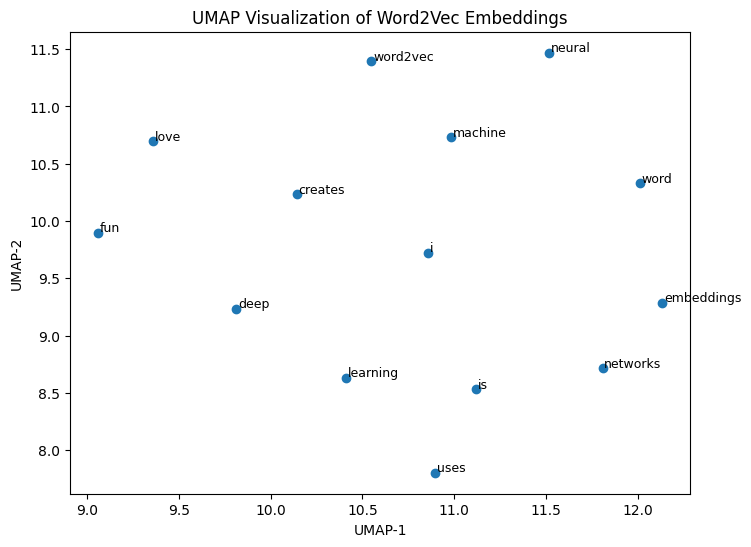

In [2]:
from gensim.models import Word2Vec

sentences = [
    ["i", "love", "machine", "learning"],
    ["machine", "learning", "is", "fun"],
    ["i", "love", "deep", "learning"],
    ["deep", "learning", "uses", "neural", "networks"],
    ["word2vec", "creates", "word", "embeddings"]
]

model = Word2Vec(
    sentences,
    vector_size=50,
    window=3,
    min_count=1,
    sg=1
)

# Step 3: Prepare embeddings for UMAP
import numpy as np

words = list(model.wv.index_to_key)
vectors = np.array([model.wv[word] for word in words])


# Step 4: Apply UMAP (2D projection)
import umap

umap_model = umap.UMAP(
    n_neighbors=5,
    min_dist=0.3,
    n_components=2,
    random_state=42
)

embeddings_2d = umap_model.fit_transform(vectors)

# Step 5: Visualize using Matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1])

for i, word in enumerate(words):
    plt.text(
        embeddings_2d[i, 0] + 0.01,
        embeddings_2d[i, 1] + 0.01,
        word,
        fontsize=9
    )

plt.title("UMAP Visualization of Word2Vec Embeddings")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()



#### Training a Movie review model